# 03 Benchmark Species

Benchmark des architectures pour la classification d'espece.

Execution volontairement manuelle: chaque architecture a sa propre cellule. Tu peux en lancer une, interrompre, redemarrer le kernel, puis continuer plus tard sans perdre le comparatif deja sauvegarde.

## DagsHub / MLflow

Avant de lancer les cellules d'entrainement:
- creer le repo DagsHub lie au repo GitHub si ce n'est pas deja fait,
- verifier `.env` avec `MLFLOW_TRACKING_URI`, `MLFLOW_TRACKING_USERNAME`, `MLFLOW_TRACKING_PASSWORD`,
- lancer le notebook en local depuis l'environnement GPU.

Tu n'as pas besoin de pousser sur GitHub avant chaque run: MLflow logge directement depuis ta machine vers DagsHub. Pour les gros runs de benchmark, pousse quand meme ton code avant de commencer afin de pouvoir relier les resultats a une version claire du projet.

In [1]:
import json
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import tensorflow as tf

for gpu in tf.config.list_physical_devices("GPU"):
    tf.config.experimental.set_memory_growth(gpu, True)
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    top_k_accuracy_score,
)
from sklearn.utils.class_weight import compute_class_weight

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.core.mlflow_config import setup_mlflow
from src.data.augmentation import IMAGE_SIZE
from src.models.build import (
    build_model,
    densenet_preprocess_input,
    list_available_architectures,
    list_recommended_screening_architectures,
    resnet_v2_preprocess_input,
)
from src.models.train import TrainingConfig, train_model

tracking_uri = setup_mlflow(experiment_name="species-benchmark")
tracking_uri


2026-04-16 11:58:10.707641: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-16 11:58:10.884631: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776333490.948604    5056 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776333490.969474    5056 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776333491.132169    5056 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

'https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow'

In [2]:
SEED = 42
TRAIN_BATCH_SIZE = 32
EVAL_BATCH_SIZE = 8
PREFETCH_BUFFER_SIZE = 1
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".tif", ".tiff"}
DATA_ROOT = REPO_ROOT / "data" / "processed" / "species"
TRAIN_DIR = DATA_ROOT / "train"
VAL_DIR = DATA_ROOT / "val"
TEST_DIR = DATA_ROOT / "test"
OOD_ROOT = REPO_ROOT / "data" / "test_ood"
MODEL_ROOT = REPO_ROOT / "models" / "species"
HISTORY_ROOT = MODEL_ROOT / "histories"
RESULTS_PATH = MODEL_ROOT / "benchmark_results.csv"

if not TRAIN_DIR.exists() or not VAL_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        f"Dossiers attendus introuvables: {TRAIN_DIR}, {VAL_DIR}, {TEST_DIR}. "
        "Relance l'etape 4 avec le split train/val/test avant ce benchmark."
    )

MODEL_ROOT.mkdir(parents=True, exist_ok=True)
HISTORY_ROOT.mkdir(parents=True, exist_ok=True)

train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)
val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    label_mode="int",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=EVAL_BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
AUTOTUNE = tf.data.AUTOTUNE

train_labels = []
for class_index, class_name in enumerate(class_names):
    class_dir = TRAIN_DIR / class_name
    image_count = sum(
        1
        for path in class_dir.iterdir()
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )
    train_labels.extend([class_index] * image_count)

class_indices = np.arange(NUM_CLASSES)
class_weight_values = compute_class_weight(
    class_weight="balanced",
    classes=class_indices,
    y=np.array(train_labels),
)
class_weight = {
    int(class_index): float(weight)
    for class_index, weight in zip(class_indices, class_weight_values)
}
class_weight_df = pd.DataFrame(
    {
        "class_index": class_indices,
        "class_name": class_names,
        "class_weight": class_weight_values,
    }
)


def load_raw_image(image_path: tf.Tensor, label: tf.Tensor) -> tuple[tf.Tensor, tf.Tensor]:
    image_bytes = tf.io.read_file(image_path)
    image = tf.io.decode_image(image_bytes, channels=3, expand_animations=False)
    image.set_shape((None, None, 3))
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))
    return image, label


def build_ood_species_dataset() -> tuple[tf.data.Dataset | None, pd.DataFrame]:
    records = []
    if not OOD_ROOT.exists():
        return None, pd.DataFrame()

    for class_index, class_name in enumerate(class_names):
        species_dir = OOD_ROOT / class_name
        if not species_dir.exists():
            continue
        for image_path in sorted(species_dir.rglob("*")):
            if image_path.is_file() and image_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append(
                    {
                        "image_path": str(image_path),
                        "class_index": class_index,
                        "class_name": class_name,
                    }
                )

    frame = pd.DataFrame(records)
    if frame.empty:
        return None, frame

    dataset = tf.data.Dataset.from_tensor_slices(
        (
            frame["image_path"].to_numpy(),
            frame["class_index"].to_numpy(dtype="int32"),
        )
    )
    dataset = dataset.map(load_raw_image, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(EVAL_BATCH_SIZE).prefetch(PREFETCH_BUFFER_SIZE)
    return dataset, frame


train_ds = train_ds.prefetch(PREFETCH_BUFFER_SIZE)
val_ds = val_ds.prefetch(PREFETCH_BUFFER_SIZE)
test_ds = test_ds.prefetch(PREFETCH_BUFFER_SIZE)
ood_species_ds, ood_species_df = build_ood_species_dataset()

class_weight_df, ood_species_df.groupby("class_name").size().rename("ood_count")


Found 47125 files belonging to 7 classes.


I0000 00:00:1776333495.885482    5056 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21452 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Found 10101 files belonging to 7 classes.
Found 10092 files belonging to 7 classes.


(   class_index  class_name  class_weight
 0            0       apple      0.990021
 1            1        corn      1.051569
 2            2       grape      1.065550
 3            3      pepper      1.971922
 4            4      potato      1.349127
 5            5  strawberry      2.137867
 6            6      tomato      0.419396,
 class_name
 apple         287
 corn          378
 grape         154
 pepper        125
 potato        379
 strawberry     96
 tomato        903
 Name: ood_count, dtype: int64)

In [30]:
SCREENING_ARCHITECTURES = list_recommended_screening_architectures()
DEFERRED_ARCHITECTURES = [
    "EfficientNetB3",
    "ResNet50V2",
    "ResNet101V2",
    "ConvNeXtSmall",
    "DenseNet169",
]
ARCHITECTURE_FAMILY = {
    "MobileNetV3Small": "MobileNet",
    "MobileNetV3Large": "MobileNet",
    "EfficientNetB0": "EfficientNet",
    "EfficientNetB1": "EfficientNet",
    "EfficientNetB3": "EfficientNet",
    "ResNet50V2": "ResNet",
    "ResNet101V2": "ResNet",
    "ConvNeXtTiny": "ConvNeXt",
    "ConvNeXtSmall": "ConvNeXt",
    "DenseNet121": "DenseNet",
    "DenseNet169": "DenseNet",
}
SCREENING_RANKING_METRICS = [
    ("eval_val_f1_macro", 0.30, True),
    ("eval_val_balanced_accuracy", 0.20, True),
    ("eval_val_log_loss", 0.20, False),
    ("eval_val_ms_per_image", 0.15, False),
    ("loss_gap", 0.10, False),
    ("overfit_gap", 0.05, False),
]
FINAL_RANKING_METRICS = [
    ("eval_test_f1_macro", 0.25, True),
    ("eval_test_balanced_accuracy", 0.20, True),
    ("eval_ood_f1_macro", 0.20, True),
    ("eval_ood_balanced_accuracy", 0.15, True),
    ("eval_test_log_loss", 0.10, False),
    ("eval_test_ms_per_image", 0.05, False),
    ("loss_gap", 0.05, False),
]
DEFAULT_FINE_TUNE_LAYERS = [20, 50]
DEFAULT_FINE_TUNE_LR = [1e-5, 3e-5]
PREPROCESSOR_CUSTOM_OBJECTS = {
    "DenseNet121": {
        "preprocess_input": tf.keras.applications.densenet.preprocess_input,
        "densenet_preprocess_input": densenet_preprocess_input,
        "plant_disease>densenet_preprocess_input": densenet_preprocess_input,
    },
    "DenseNet169": {
        "preprocess_input": tf.keras.applications.densenet.preprocess_input,
        "densenet_preprocess_input": densenet_preprocess_input,
        "plant_disease>densenet_preprocess_input": densenet_preprocess_input,
    },
    "ResNet50V2": {
        "preprocess_input": tf.keras.applications.resnet_v2.preprocess_input,
        "resnet_v2_preprocess_input": resnet_v2_preprocess_input,
        "plant_disease>resnet_v2_preprocess_input": resnet_v2_preprocess_input,
    },
    "ResNet101V2": {
        "preprocess_input": tf.keras.applications.resnet_v2.preprocess_input,
        "resnet_v2_preprocess_input": resnet_v2_preprocess_input,
        "plant_disease>resnet_v2_preprocess_input": resnet_v2_preprocess_input,
    },
}
SCREENING_RESULTS_PATH = MODEL_ROOT / "screening_results.csv"
FINE_TUNE_RESULTS_PATH = MODEL_ROOT / "finetune_results.csv"

missing_architectures = sorted(
    set(SCREENING_ARCHITECTURES + DEFERRED_ARCHITECTURES) - set(list_available_architectures())
)
if missing_architectures:
    raise ValueError(f"Architectures indisponibles: {missing_architectures}")

benchmark_results = {}
trained_models = {}
evaluation_details = {}


def safe_run_name(value: str) -> str:
    return value.strip().replace("/", "_").replace(" ", "_").replace(".", "p").replace("-", "_")


def sort_summary(summary: pd.DataFrame) -> pd.DataFrame:
    for column in ["eval_test_f1_macro", "eval_ood_f1_macro", "eval_val_f1_macro"]:
        if column in summary.columns:
            return summary.sort_values(column, ascending=False)
    return summary


def load_summary(results_path: Path = FINE_TUNE_RESULTS_PATH) -> pd.DataFrame:
    if results_path.exists():
        return sort_summary(pd.read_csv(results_path))
    return pd.DataFrame()


def save_result(row: dict[str, object], results_path: Path) -> pd.DataFrame:
    summary = load_summary(results_path)
    if not summary.empty and "run_name" in summary.columns:
        summary = summary[summary["run_name"] != row["run_name"]]
    summary = pd.concat([summary, pd.DataFrame([row])], ignore_index=True)
    summary = sort_summary(summary)
    summary.to_csv(results_path, index=False)
    return summary


def save_history(run_name: str, result: dict[str, object]) -> Path:
    history_path = HISTORY_ROOT / f"{run_name}_history.json"
    payload = {
        "phase1": result["phase1_history"],
        "phase2": result["phase2_history"],
    }
    history_path.write_text(json.dumps(payload, indent=2), encoding="utf-8")
    return history_path


def load_history(run_name: str) -> dict[str, dict[str, list[float]]]:
    history_path = HISTORY_ROOT / f"{run_name}_history.json"
    if not history_path.exists():
        raise FileNotFoundError(
            f"Historique introuvable pour {run_name}. "
            "Lance d'abord la cellule d'entrainement correspondante."
        )
    return json.loads(history_path.read_text(encoding="utf-8"))


def predict_species_dataset(
    model: tf.keras.Model,
    dataset: tf.data.Dataset,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, int, float]:
    y_true = []
    y_score_batches = []
    image_count = 0
    started_at = time.perf_counter()

    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        y_score_batches.append(predictions)
        y_true.extend(labels.numpy().astype(int).tolist())
        image_count += int(images.shape[0])

    elapsed = time.perf_counter() - started_at
    y_score = np.concatenate(y_score_batches, axis=0)
    y_true = np.array(y_true, dtype="int32")
    y_pred = np.argmax(y_score, axis=1)
    return y_true, y_pred, y_score, image_count, elapsed


def evaluate_species_model(
    run_name: str,
    architecture: str,
    model: tf.keras.Model,
    dataset: tf.data.Dataset,
    eval_name: str,
) -> dict[str, float]:
    y_true, y_pred, y_score, image_count, elapsed = predict_species_dataset(model, dataset)
    labels = np.arange(NUM_CLASSES)
    accuracy = float(accuracy_score(y_true, y_pred))
    top_k = min(2, NUM_CLASSES - 1) if NUM_CLASSES > 2 else 1

    metrics = {
        f"eval_{eval_name}_accuracy": accuracy,
        f"eval_{eval_name}_error_rate": float(1.0 - accuracy),
        f"eval_{eval_name}_balanced_accuracy": float(
            balanced_accuracy_score(y_true, y_pred)
        ),
        f"eval_{eval_name}_precision_macro": float(
            precision_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        f"eval_{eval_name}_recall_macro": float(
            recall_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        f"eval_{eval_name}_f1_macro": float(
            f1_score(y_true, y_pred, average="macro", zero_division=0)
        ),
        f"eval_{eval_name}_log_loss": float(log_loss(y_true, y_score, labels=labels)),
        f"eval_{eval_name}_ms_per_image": float((elapsed / image_count) * 1000),
    }
    if top_k > 1:
        metrics[f"eval_{eval_name}_top{top_k}_accuracy"] = float(
            top_k_accuracy_score(y_true, y_score, k=top_k, labels=labels)
        )

    evaluation_details[(run_name, eval_name)] = {
        "y_true": y_true,
        "y_pred": y_pred,
        "y_score": y_score,
        "metrics": metrics,
    }

    try:
        with mlflow.start_run(run_name=f"{run_name}_eval_{eval_name}"):
            mlflow.log_params(
                {
                    "architecture": architecture,
                    "run_name": run_name,
                    "task": "species",
                    "phase": f"eval_{eval_name}",
                }
            )
            mlflow.log_metrics(metrics)
    except Exception as exc:
        print(
            f"Warning MLflow: logging evaluation {run_name}/{eval_name} ignore: {exc}"
        )

    return metrics


def best_metric(history: dict[str, list[float]], name: str) -> float | None:
    values = history.get(name, [])
    if not values:
        return None
    return float(min(values) if "loss" in name else max(values))


def overfit_gap(history: dict[str, list[float]]) -> float | None:
    accuracy = history.get("accuracy", [])
    val_accuracy = history.get("val_accuracy", [])
    if not accuracy or not val_accuracy:
        return None
    return float(accuracy[-1] - val_accuracy[-1])


def loss_gap(history: dict[str, list[float]]) -> float | None:
    loss = history.get("loss", [])
    val_loss = history.get("val_loss", [])
    if not loss or not val_loss:
        return None
    return float(val_loss[-1] - loss[-1])


def diagnose_overfitting(history: dict[str, list[float]]) -> str:
    accuracy_gap = overfit_gap(history)
    validation_loss_gap = loss_gap(history)
    val_loss = history.get("val_loss", [])

    if accuracy_gap is None or validation_loss_gap is None or len(val_loss) < 2:
        return "diagnostic_indisponible"

    val_loss_worsens = val_loss[-1] > min(val_loss[:-1]) * 1.05
    if accuracy_gap > 0.05 and validation_loss_gap > 0.20 and val_loss_worsens:
        return "overfitting_probable"
    if accuracy_gap > 0.03 or validation_loss_gap > 0.10:
        return "a_surveilleiller"
    return "pas_d_overfitting_significatif"


def build_result_row(
    *,
    run_name: str,
    architecture: str,
    stage: str,
    result: dict[str, object],
    history_path: Path,
    phase1_learning_rate: float,
    phase2_learning_rate: float | None,
    fine_tune_layers: int,
    eval_metrics: dict[str, float],
) -> dict[str, object]:
    phase1_history = result["phase1_history"]
    phase2_history = result["phase2_history"]
    diagnostic_history = phase2_history or phase1_history

    return {
        "run_name": run_name,
        "architecture": architecture,
        "architecture_family": ARCHITECTURE_FAMILY.get(architecture, "unknown"),
        "stage": stage,
        "phase1_learning_rate": phase1_learning_rate,
        "phase2_learning_rate": phase2_learning_rate,
        "fine_tuned_layers": result["fine_tuned_layers"],
        "requested_fine_tune_layers": fine_tune_layers,
        "phase1_best_val_accuracy": best_metric(phase1_history, "val_accuracy"),
        "phase1_best_val_loss": best_metric(phase1_history, "val_loss"),
        "phase2_best_val_accuracy": best_metric(phase2_history, "val_accuracy"),
        "phase2_best_val_loss": best_metric(phase2_history, "val_loss"),
        "overfit_gap": overfit_gap(diagnostic_history),
        "loss_gap": loss_gap(diagnostic_history),
        "overfit_diagnostic": diagnose_overfitting(diagnostic_history),
        "checkpoint_path": str(result["checkpoint_path"]),
        "history_path": str(history_path),
        "class_weight": str(class_weight),
        **eval_metrics,
    }


def load_species_checkpoint(architecture: str, checkpoint_path: Path) -> tf.keras.Model:
    return tf.keras.models.load_model(
        str(checkpoint_path),
        compile=False,
        safe_mode=False,
        custom_objects=PREPROCESSOR_CUSTOM_OBJECTS.get(architecture, {}),
    )


def evaluate_checkpoint(
    *,
    run_name: str,
    architecture: str,
    checkpoint_path: Path,
    include_test: bool,
    include_ood: bool,
    keep_model: bool,
) -> dict[str, float]:
    tf.keras.backend.clear_session()
    eval_model = load_species_checkpoint(architecture, checkpoint_path)

    eval_metrics = evaluate_species_model(run_name, architecture, eval_model, val_ds, "val")
    if include_test:
        eval_metrics.update(
            evaluate_species_model(run_name, architecture, eval_model, test_ds, "test")
        )
    if include_ood and ood_species_ds is not None:
        eval_metrics.update(
            evaluate_species_model(run_name, architecture, eval_model, ood_species_ds, "ood")
        )

    if keep_model:
        trained_models[run_name] = eval_model
    else:
        del eval_model
        tf.keras.backend.clear_session()

    return eval_metrics


def run_species_phase1_screening(
    architecture: str,
    *,
    phase1_epochs: int = 4,
    phase1_learning_rate: float = 1e-3,
    include_ood: bool = False,
    keep_model: bool = False,
) -> pd.DataFrame:
    run_name = safe_run_name(f"{architecture}_screening")
    training_model = build_model(architecture=architecture, num_classes=NUM_CLASSES)
    config = TrainingConfig(
        phase1_epochs=phase1_epochs,
        phase2_epochs=0,
        phase1_learning_rate=phase1_learning_rate,
        checkpoint_root=MODEL_ROOT,
    )

    result = train_model(
        model=training_model,
        train_data=train_ds,
        val_data=val_ds,
        architecture=architecture,
        task="species_screening",
        config=config,
        class_weight=class_weight,
        log_to_mlflow=True,
    )
    history_path = save_history(run_name, result)
    del training_model

    eval_metrics = evaluate_checkpoint(
        run_name=run_name,
        architecture=architecture,
        checkpoint_path=result["checkpoint_path"],
        include_test=False,
        include_ood=include_ood,
        keep_model=keep_model,
    )
    row = build_result_row(
        run_name=run_name,
        architecture=architecture,
        stage="screening_phase1",
        result=result,
        history_path=history_path,
        phase1_learning_rate=phase1_learning_rate,
        phase2_learning_rate=None,
        fine_tune_layers=0,
        eval_metrics=eval_metrics,
    )
    return save_result(row, SCREENING_RESULTS_PATH)


def run_species_fine_tuning(
    architecture: str,
    *,
    fine_tune_layers: int = 50,
    phase2_learning_rate: float = 1e-5,
    phase2_epochs: int = 10,
    include_ood: bool = True,
    keep_model: bool = False,
) -> pd.DataFrame:
    lr_name = safe_run_name(f"{phase2_learning_rate:.0e}")
    run_name = safe_run_name(f"{architecture}_ft_l{fine_tune_layers}_lr{lr_name}")
    screening_checkpoint = MODEL_ROOT / f"{architecture}_species_screening" / "best_model.keras"
    if not screening_checkpoint.exists():
        raise FileNotFoundError(
            f"Checkpoint phase 1 introuvable pour {architecture}: {screening_checkpoint}. "
            "Lance d'abord la cellule de screening de ce modele."
        )

    tf.keras.backend.clear_session()
    training_model = load_species_checkpoint(architecture, screening_checkpoint)
    config = TrainingConfig(
        phase1_epochs=0,
        phase2_epochs=phase2_epochs,
        phase2_learning_rate=phase2_learning_rate,
        fine_tune_layers=fine_tune_layers,
        checkpoint_root=MODEL_ROOT,
    )

    result = train_model(
        model=training_model,
        train_data=train_ds,
        val_data=val_ds,
        architecture=architecture,
        task=f"species_ft_l{fine_tune_layers}_lr{lr_name}",
        config=config,
        class_weight=class_weight,
        log_to_mlflow=True,
    )
    history_path = save_history(run_name, result)
    del training_model

    eval_metrics = evaluate_checkpoint(
        run_name=run_name,
        architecture=architecture,
        checkpoint_path=result["checkpoint_path"],
        include_test=True,
        include_ood=include_ood,
        keep_model=keep_model,
    )
    row = build_result_row(
        run_name=run_name,
        architecture=architecture,
        stage="fine_tuning",
        result=result,
        history_path=history_path,
        phase1_learning_rate=1e-3,
        phase2_learning_rate=phase2_learning_rate,
        fine_tune_layers=fine_tune_layers,
        eval_metrics=eval_metrics,
    )
    return save_result(row, FINE_TUNE_RESULTS_PATH)


def recover_fine_tune_from_checkpoint(
    architecture: str,
    *,
    fine_tune_layers: int = 50,
    phase2_learning_rate: float = 1e-5,
    include_ood: bool = True,
    keep_model: bool = False,
) -> pd.DataFrame:
    """Evaluate an already-saved fine-tuned checkpoint after a late MLflow failure."""

    lr_name = safe_run_name(f"{phase2_learning_rate:.0e}")
    run_name = safe_run_name(f"{architecture}_ft_l{fine_tune_layers}_lr{lr_name}")
    checkpoint_path = (
        MODEL_ROOT
        / f"{architecture}_species_ft_l{fine_tune_layers}_lr{lr_name}"
        / "best_model.keras"
    )
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Checkpoint fine-tune introuvable: {checkpoint_path}")

    result = {
        "checkpoint_path": checkpoint_path,
        "fine_tuned_layers": fine_tune_layers,
        "phase1_history": {},
        "phase2_history": {},
    }
    history_path = HISTORY_ROOT / f"{run_name}_history.json"
    if not history_path.exists():
        history_path = save_history(run_name, result)

    eval_metrics = evaluate_checkpoint(
        run_name=run_name,
        architecture=architecture,
        checkpoint_path=checkpoint_path,
        include_test=True,
        include_ood=include_ood,
        keep_model=keep_model,
    )
    row = build_result_row(
        run_name=run_name,
        architecture=architecture,
        stage="fine_tuning_recovered",
        result=result,
        history_path=history_path,
        phase1_learning_rate=1e-3,
        phase2_learning_rate=phase2_learning_rate,
        fine_tune_layers=fine_tune_layers,
        eval_metrics=eval_metrics,
    )
    row["overfit_diagnostic"] = "historique_indisponible_apres_echec_mlflow"
    return save_result(row, FINE_TUNE_RESULTS_PATH)



def current_finalist_architectures(top_k: int = 4) -> list[str]:
    if "finalist_architectures" in globals() and finalist_architectures:
        return list(finalist_architectures)
    return select_screening_finalists(top_k=top_k)


def get_finalist_architecture(finalist_rank: int, *, top_k: int = 4) -> str:
    finalists = current_finalist_architectures(top_k=top_k)
    if finalist_rank < 1 or finalist_rank > len(finalists):
        raise IndexError(
            f"Finaliste {finalist_rank} indisponible. "
            f"Finalistes actuels: {finalists}"
        )
    return finalists[finalist_rank - 1]


def fine_tune_run_name(
    architecture: str,
    *,
    fine_tune_layers: int = 50,
    phase2_learning_rate: float = 1e-5,
) -> str:
    lr_name = safe_run_name(f"{phase2_learning_rate:.0e}")
    return safe_run_name(f"{architecture}_ft_l{fine_tune_layers}_lr{lr_name}")


def run_finalist_fine_tuning(
    finalist_rank: int,
    *,
    fine_tune_layers: int = 50,
    phase2_learning_rate: float = 1e-5,
    phase2_epochs: int = 10,
    include_ood: bool = True,
    keep_model: bool = False,
) -> pd.DataFrame:
    architecture = get_finalist_architecture(finalist_rank)
    print(f"Fine-tuning finaliste {finalist_rank}: {architecture}")
    return run_species_fine_tuning(
        architecture,
        fine_tune_layers=fine_tune_layers,
        phase2_learning_rate=phase2_learning_rate,
        phase2_epochs=phase2_epochs,
        include_ood=include_ood,
        keep_model=keep_model,
    )


def inspect_finalist_fine_tuning(
    finalist_rank: int,
    *,
    fine_tune_layers: int = 50,
    phase2_learning_rate: float = 1e-5,
) -> pd.DataFrame:
    architecture = get_finalist_architecture(finalist_rank)
    run_name = fine_tune_run_name(
        architecture,
        fine_tune_layers=fine_tune_layers,
        phase2_learning_rate=phase2_learning_rate,
    )
    return inspect_model_results(run_name)


def run_screening_shortlist() -> pd.DataFrame:
    for architecture in SCREENING_ARCHITECTURES:
        run_species_phase1_screening(architecture)
    return rank_screening_results()


def add_ranking_score(
    summary: pd.DataFrame,
    metric_specs: list[tuple[str, float, bool]],
) -> pd.DataFrame:
    if summary.empty:
        return summary

    ranked = summary.copy()
    score_columns = []
    for metric, weight, higher_is_better in metric_specs:
        if metric not in ranked.columns:
            continue
        values = pd.to_numeric(ranked[metric], errors="coerce")
        if values.notna().sum() == 0:
            continue
        filled_values = values.fillna(values.min() if higher_is_better else values.max())
        score_column = f"score_{metric}"
        ranked[score_column] = filled_values.rank(
            method="average",
            pct=True,
            ascending=higher_is_better,
        ) * weight
        score_columns.append(score_column)

    if not score_columns:
        return ranked

    ranked["ranking_score"] = ranked[score_columns].sum(axis=1)
    ranked["ranking_position"] = ranked["ranking_score"].rank(
        method="first",
        ascending=False,
    ).astype(int)
    return ranked.sort_values(
        ["ranking_score", "eval_val_f1_macro"],
        ascending=[False, False],
    )


def select_diverse_ranked_runs(
    ranked: pd.DataFrame,
    *,
    top_k: int,
    max_per_family: int = 1,
) -> pd.DataFrame:
    if ranked.empty:
        return ranked

    selected_indices = []
    family_counts: dict[str, int] = {}
    for row_index, row in ranked.iterrows():
        family = row.get("architecture_family", "unknown")
        if family_counts.get(family, 0) >= max_per_family:
            continue
        selected_indices.append(row_index)
        family_counts[family] = family_counts.get(family, 0) + 1
        if len(selected_indices) == top_k:
            return ranked.loc[selected_indices]

    for row_index, row in ranked.iterrows():
        if row_index in selected_indices:
            continue
        selected_indices.append(row_index)
        if len(selected_indices) == top_k:
            break
    return ranked.loc[selected_indices]


def rank_screening_results() -> pd.DataFrame:
    return add_ranking_score(load_summary(SCREENING_RESULTS_PATH), SCREENING_RANKING_METRICS)


def rank_fine_tune_results() -> pd.DataFrame:
    return add_ranking_score(load_summary(FINE_TUNE_RESULTS_PATH), FINAL_RANKING_METRICS)


def select_screening_finalists(top_k: int = 4) -> list[str]:
    ranked = rank_screening_results()
    selected = select_diverse_ranked_runs(ranked, top_k=top_k, max_per_family=2)
    return selected["architecture"].tolist() if not selected.empty else []


def select_final_ensemble(
    top_k: int = 3,
    *,
    max_per_family: int = 2,
    min_score_ratio_for_diversity: float = 0.85,
) -> pd.DataFrame:
    ranked = rank_fine_tune_results()
    if ranked.empty:
        return ranked

    selected_indices = []
    family_counts = {}

    for row_index, row in ranked.iterrows():
        family = row.get("architecture_family", "unknown")
        if family_counts.get(family, 0) >= max_per_family:
            continue

        selected_indices.append(row_index)
        family_counts[family] = family_counts.get(family, 0) + 1

        if len(selected_indices) == top_k:
            break

    selected = ranked.loc[selected_indices]
    if len(selected) < top_k:
        return ranked.head(top_k)

    weakest_selected_score = selected["ranking_score"].min()
    best_rejected = ranked.drop(index=selected_indices).head(1)

    if best_rejected.empty:
        return selected

    best_rejected_score = best_rejected["ranking_score"].iloc[0]

    if weakest_selected_score < best_rejected_score * min_score_ratio_for_diversity:
        return ranked.head(top_k)

    return selected


def plot_training_curves(run_name: str) -> None:
    history = load_history(run_name)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for phase, phase_history in history.items():
        if not phase_history:
            continue
        label = phase.replace("phase", "phase ")
        axes[0].plot(phase_history.get("loss", []), label=f"{label} train")
        axes[0].plot(phase_history.get("val_loss", []), label=f"{label} val")
        axes[1].plot(phase_history.get("accuracy", []), label=f"{label} train")
        axes[1].plot(phase_history.get("val_accuracy", []), label=f"{label} val")

    axes[0].set_title(f"{run_name} - loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[1].set_title(f"{run_name} - accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    plt.tight_layout()
    plt.show()


def classification_report_df(run_name: str, eval_name: str = "test") -> pd.DataFrame:
    details = evaluation_details.get((run_name, eval_name))
    if details is None:
        return pd.DataFrame()

    report = classification_report(
        details["y_true"],
        details["y_pred"],
        labels=np.arange(NUM_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    return pd.DataFrame(report).transpose()


def plot_confusion_matrix(
    run_name: str,
    eval_name: str = "test",
    normalize: bool = True,
) -> pd.DataFrame:
    details = evaluation_details.get((run_name, eval_name))
    if details is None:
        return pd.DataFrame()

    matrix = confusion_matrix(
        details["y_true"],
        details["y_pred"],
        labels=np.arange(NUM_CLASSES),
        normalize="true" if normalize else None,
    )
    matrix_df = pd.DataFrame(matrix, index=class_names, columns=class_names)

    fig, ax = plt.subplots(figsize=(8, 6))
    image = ax.imshow(matrix_df.values, cmap="Blues", vmin=0, vmax=1 if normalize else None)
    ax.set_title(f"{run_name} - matrice de confusion {eval_name}")
    ax.set_xlabel("Prediction")
    ax.set_ylabel("Vrai label")
    ax.set_xticks(np.arange(NUM_CLASSES), labels=class_names, rotation=45, ha="right")
    ax.set_yticks(np.arange(NUM_CLASSES), labels=class_names)
    fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)

    value_format = ".2f" if normalize else ".0f"
    for row_index in range(NUM_CLASSES):
        for column_index in range(NUM_CLASSES):
            value = matrix_df.iloc[row_index, column_index]
            ax.text(
                column_index,
                row_index,
                format(value, value_format),
                ha="center",
                va="center",
                color="white" if value > 0.5 else "black",
                fontsize=8,
            )

    plt.tight_layout()
    plt.show()
    return matrix_df


def inspect_model_results(
    run_name: str,
    *,
    results_path: Path = FINE_TUNE_RESULTS_PATH,
    eval_name: str = "test",
) -> pd.DataFrame:
    plot_training_curves(run_name)
    summary = load_summary(results_path)
    model_summary = summary[summary["run_name"] == run_name] if not summary.empty else summary
    display(model_summary)
    if not model_summary.empty and "overfit_diagnostic" in model_summary.columns:
        diagnostic = model_summary["overfit_diagnostic"].iloc[0]
        accuracy_gap = model_summary.get("overfit_gap", pd.Series([None])).iloc[0]
        validation_loss_gap = model_summary.get("loss_gap", pd.Series([None])).iloc[0]
        print(
            f"Diagnostic overfitting: {diagnostic} "
            f"(gap accuracy train-val={accuracy_gap:.4f}, "
            f"gap loss val-train={validation_loss_gap:.4f})"
        )

    report = classification_report_df(run_name, eval_name=eval_name)
    if report.empty:
        print(
            "Rapport par classe et matrice de confusion disponibles apres avoir "
            "evalue ce run dans la session notebook courante."
        )
    else:
        display(report)
        plot_confusion_matrix(run_name, eval_name=eval_name)

    return model_summary

SCREENING_ARCHITECTURES, DEFERRED_ARCHITECTURES, rank_screening_results()


(['MobileNetV3Small',
  'MobileNetV3Large',
  'EfficientNetB0',
  'EfficientNetB1',
  'ConvNeXtTiny',
  'DenseNet121'],
 ['EfficientNetB3',
  'ResNet50V2',
  'ResNet101V2',
  'ConvNeXtSmall',
  'DenseNet169'],
                      run_name      architecture architecture_family  \
 0  MobileNetV3Large_screening  MobileNetV3Large           MobileNet   
 2    EfficientNetB0_screening    EfficientNetB0        EfficientNet   
 1      ConvNeXtTiny_screening      ConvNeXtTiny            ConvNeXt   
 3    EfficientNetB1_screening    EfficientNetB1        EfficientNet   
 4  MobileNetV3Small_screening  MobileNetV3Small           MobileNet   
 5       DenseNet121_screening       DenseNet121            DenseNet   
 
               stage  phase1_learning_rate  phase2_learning_rate  \
 0  screening_phase1                 0.001                   NaN   
 2  screening_phase1                 0.001                   NaN   
 1  screening_phase1                 0.001                   NaN   
 3  screenin

## Phase 1 - Screening rapide

On entraine uniquement la tete de classification avec le backbone gele. Cette etape sert a filtrer vite plusieurs familles d'architectures sans payer le cout du fine-tuning complet.

Le ranking de screening combine F1 macro validation, balanced accuracy, log loss, temps d'inference et signaux d'overfitting. Le test set reste reserve aux finalistes fine-tunes.

In [4]:
# Option bulk si tu veux lancer toute la shortlist d'un coup.
# Sinon, laisse cette ligne commentee et utilise les cellules manuelles une architecture a la fois.
# screening_summary = run_screening_shortlist()

# rank_screening_results()

In [5]:
# finalist_architectures = select_screening_finalists(top_k=4)
# finalist_architectures

## Option - Screening manuel

Si tu ne veux pas lancer toute la shortlist, execute uniquement les cellules ci-dessous, une architecture a la fois.

### Screening - MobileNetV3Small

In [6]:
mobilenet__v3_small_screening = run_species_phase1_screening(
    "MobileNetV3Small",
    phase1_epochs=4,
)
mobilenet__v3_small_screening

2026-04-16 11:58:18.209 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / MobileNetV3Small


Epoch 1/4


I0000 00:00:1776333501.706825    5443 service.cc:152] XLA service 0x708d580150e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776333501.706870    5443 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 4090, Compute Capability 8.9
2026-04-16 11:58:21.979245: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1776333502.874719    5443 cuda_dnn.cc:529] Loaded cuDNN version 90300


  26/1473 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.2924 - loss: 2.0482

I0000 00:00:1776333507.472563    5443 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

2026-04-16 11:58:43.406676: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1326', 64 bytes spill stores, 64 bytes spill loads

2026-04-16 11:58:43.453210: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1326', 716 bytes spill stores, 720 bytes spill loads

2026-04-16 11:58:43.532641: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1326', 280 bytes spill stores, 280 bytes spill loads

2026-04-16 11:58:43.561212: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1326', 64 bytes spill stores, 64 bytes spill loads

2026-04-16 11:58:43.773020: I extern

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9106 - loss: 0.2300 - val_accuracy: 0.9738 - val_loss: 0.0798 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9545 - loss: 0.1062 - val_accuracy: 0.9785 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 18s 12ms/step - accuracy: 0.9643 - loss: 0.0853 - val_accuracy: 0.9775 - val_loss: 0.0661 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9667 - loss: 0.0795 - val_accuracy: 0.9910 - val_loss: 0.0253 - learning_rate: 0.0010
🏃 View run species_screening_MobileNetV3Small_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/9269e9f1f9f64750b7c1c68e2c16471e
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 12:00:56.335941: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🏃 View run MobileNetV3Small_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/00e9eea01fe64a4eb1b8ba0f0774fe47
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.011400,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.997741,0.994465,0.997741,0.996084,0.011400,6.667507,0.999703
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.995446,0.015524,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995446,0.004554,0.996197,0.995318,0.996197,0.995754,0.015524,7.327000,0.999604
2,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.995743,0.013397,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995743,0.004257,0.996351,0.995025,0.996351,0.995679,0.013397,6.187519,1.000000
3,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.994753,0.015875,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.994753,0.005247,0.995901,0.993569,0.995901,0.994728,0.015875,7.060839,0.999703
4,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.992278,0.022994,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.992278,0.007722,0.992050,0.992548,0.992050,0.992284,0.022994,8.197975,0.999505
5,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,None,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406


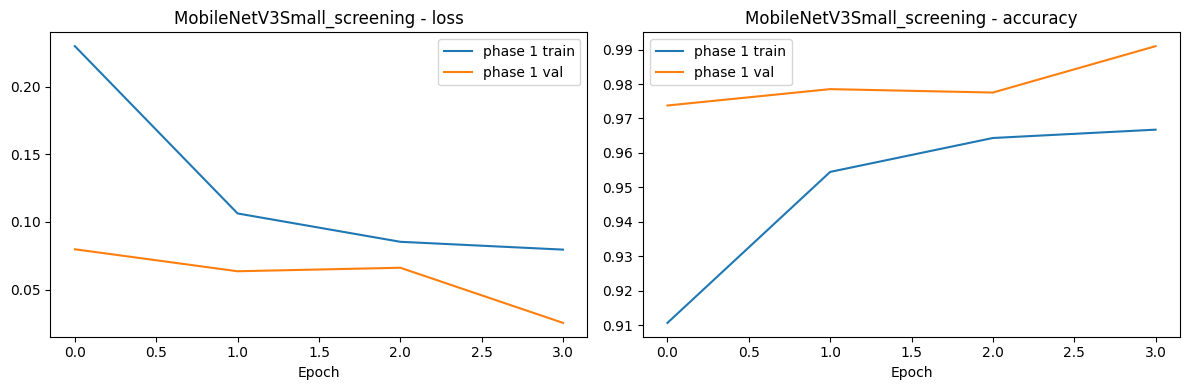

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
5,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.13206,0.999406


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0242, gap loss val-train=-0.0542)


,precision,recall,f1-score,support
apple,0.993113,0.989705,0.991406,1457.000000
corn,1.000000,1.000000,1.000000,1373.000000
grape,0.986152,0.999261,0.992663,1354.000000
pepper,0.981107,0.993169,0.987101,732.000000
potato,0.983114,0.979439,0.981273,1070.000000
strawberry,0.998503,0.988148,0.993299,675.000000
tomato,0.991543,0.988372,0.989955,3440.000000
accuracy,0.990991,0.990991,0.990991,0.990991
macro avg,0.990504,0.991156,0.990814,10101.000000
weighted avg,0.991012,0.990991,0.990990,10101.000000


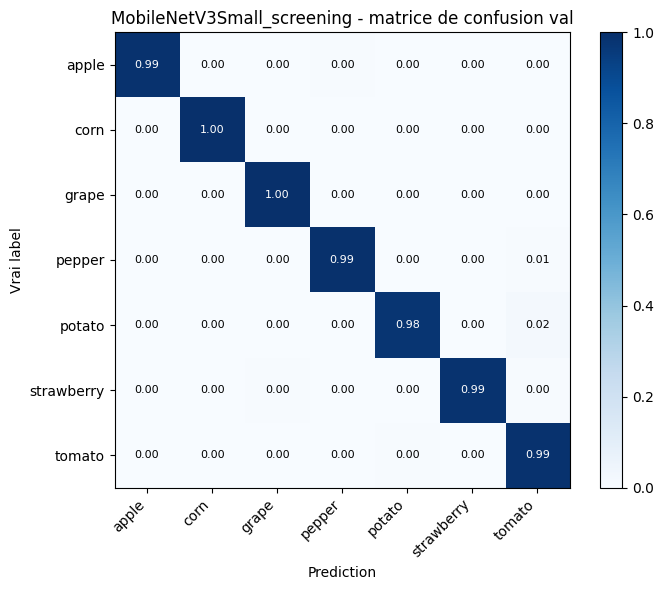

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
5,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.13206,0.999406


In [7]:
inspect_model_results(
    "MobileNetV3Small_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

### Screening - MobileNetV3Large

In [8]:
mobilenet__v3_large_screening = run_species_phase1_screening(
    "MobileNetV3Large",
    phase1_epochs=4,
)
mobilenet__v3_large_screening

2026-04-16 12:00:58.880 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / MobileNetV3Large


Epoch 1/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8998 - loss: 0.2787

2026-04-16 12:01:24.675376: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1541', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:01:24.863503: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1541', 16 bytes spill stores, 16 bytes spill loads

2026-04-16 12:01:24.893035: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1541', 248 bytes spill stores, 248 bytes spill loads

2026-04-16 12:01:24.901986: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1541', 716 bytes spill stores, 720 bytes spill loads

2026-04-16 12:01:24.937123: I extern

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.9468 - loss: 0.1417 - val_accuracy: 0.9911 - val_loss: 0.0312 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 20s 13ms/step - accuracy: 0.9741 - loss: 0.0638 - val_accuracy: 0.9934 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.9809 - loss: 0.0482 - val_accuracy: 0.9931 - val_loss: 0.0200 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.9820 - loss: 0.0448 - val_accuracy: 0.9969 - val_loss: 0.0101 - learning_rate: 0.0010
🏃 View run species_screening_MobileNetV3Large_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/79cabf4d443d4200a92e0f1ed0c46173
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 12:03:46.453516: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🏃 View run MobileNetV3Large_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/5ff9df30de114443a360b4e8b02b1f3a
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
5,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,None,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901
0,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.011400,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.997741,0.994465,0.997741,0.996084,0.011400,6.667507,0.999703
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.995446,0.015524,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995446,0.004554,0.996197,0.995318,0.996197,0.995754,0.015524,7.327000,0.999604
2,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.994753,0.015875,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.994753,0.005247,0.995901,0.993569,0.995901,0.994728,0.015875,7.060839,0.999703
3,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.992278,0.022994,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.992278,0.007722,0.992050,0.992548,0.992050,0.992284,0.022994,8.197975,0.999505
4,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406


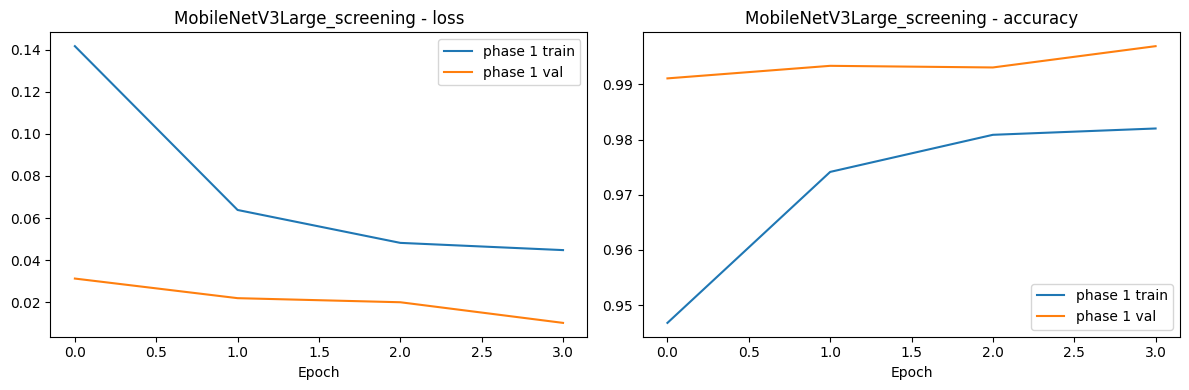

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0149, gap loss val-train=-0.0346)


,precision,recall,f1-score,support
apple,0.998625,0.997255,0.997940,1457.000000
corn,1.000000,1.000000,1.000000,1373.000000
grape,0.998525,1.000000,0.999262,1354.000000
pepper,0.994543,0.995902,0.995222,732.000000
potato,0.989729,0.990654,0.990191,1070.000000
strawberry,1.000000,1.000000,1.000000,675.000000
tomato,0.996510,0.995930,0.996220,3440.000000
accuracy,0.996931,0.996931,0.996931,0.996931
macro avg,0.996847,0.997106,0.996976,10101.000000
weighted avg,0.996932,0.996931,0.996931,10101.000000


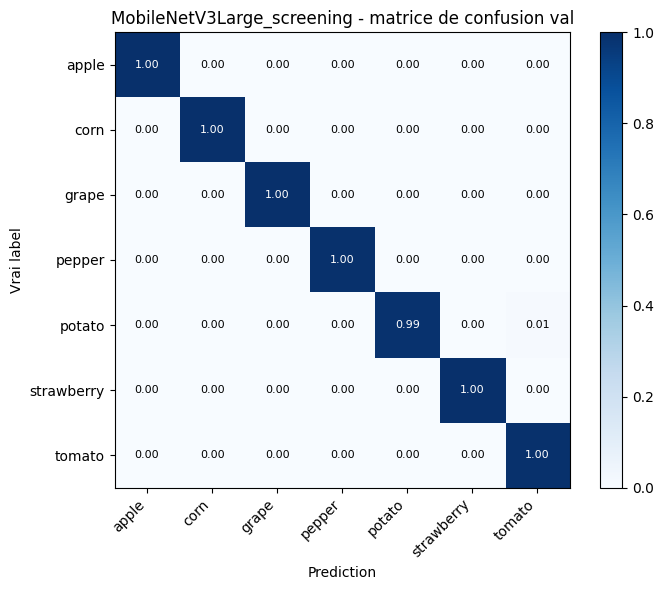

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901


In [9]:
inspect_model_results(
    "MobileNetV3Large_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

### Screening - EfficientNetB0

In [10]:
efficientnet_b0_screening = run_species_phase1_screening(
    "EfficientNetB0",
    phase1_epochs=4,
)
efficientnet_b0_screening

2026-04-16 12:03:49.497 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / EfficientNetB0


Epoch 1/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9251 - loss: 0.2145

2026-04-16 12:04:25.059115: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2050', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:04:25.281609: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2050_0', 176 bytes spill stores, 524 bytes spill loads

2026-04-16 12:04:25.320847: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2050', 104 bytes spill stores, 104 bytes spill loads

2026-04-16 12:04:25.599007: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2050', 4916 bytes spill stores, 4916 bytes spill loads

2026-04-16 12:04:25.619130: I 

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 50s 26ms/step - accuracy: 0.9612 - loss: 0.1052 - val_accuracy: 0.9860 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9802 - loss: 0.0467 - val_accuracy: 0.9888 - val_loss: 0.0315 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9845 - loss: 0.0363 - val_accuracy: 0.9926 - val_loss: 0.0210 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 24s 16ms/step - accuracy: 0.9860 - loss: 0.0320 - val_accuracy: 0.9958 - val_loss: 0.0123 - learning_rate: 0.0010
🏃 View run species_screening_EfficientNetB0_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/36506c43959e4cd4a17574803357ddd9
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0
🏃 View run EfficientNetB0_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlf

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901
5,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,None,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.995446,0.015524,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995446,0.004554,0.996197,0.995318,0.996197,0.995754,0.015524,7.327000,0.999604
2,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.994753,0.015875,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.994753,0.005247,0.995901,0.993569,0.995901,0.994728,0.015875,7.060839,0.999703
3,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.992278,0.022994,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.992278,0.007722,0.992050,0.992548,0.992050,0.992284,0.022994,8.197975,0.999505
4,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406


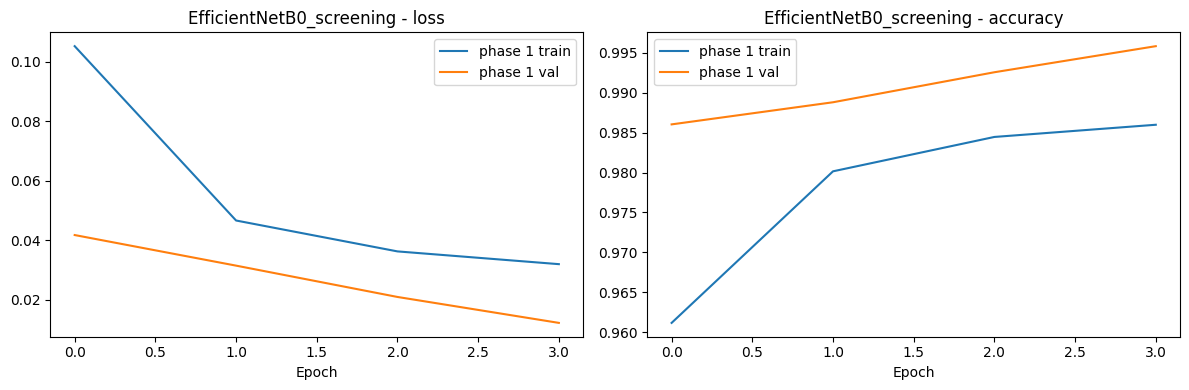

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
1,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0098, gap loss val-train=-0.0197)


,precision,recall,f1-score,support
apple,0.996571,0.997255,0.996913,1457.000000
corn,1.000000,1.000000,1.000000,1373.000000
grape,0.997052,0.999261,0.998156,1354.000000
pepper,0.991870,1.000000,0.995918,732.000000
potato,0.984230,0.991589,0.987896,1070.000000
strawberry,0.994100,0.998519,0.996305,675.000000
tomato,0.998245,0.992151,0.995189,3440.000000
accuracy,0.995842,0.995842,0.995842,0.995842
macro avg,0.994581,0.996968,0.995768,10101.000000
weighted avg,0.995859,0.995842,0.995844,10101.000000


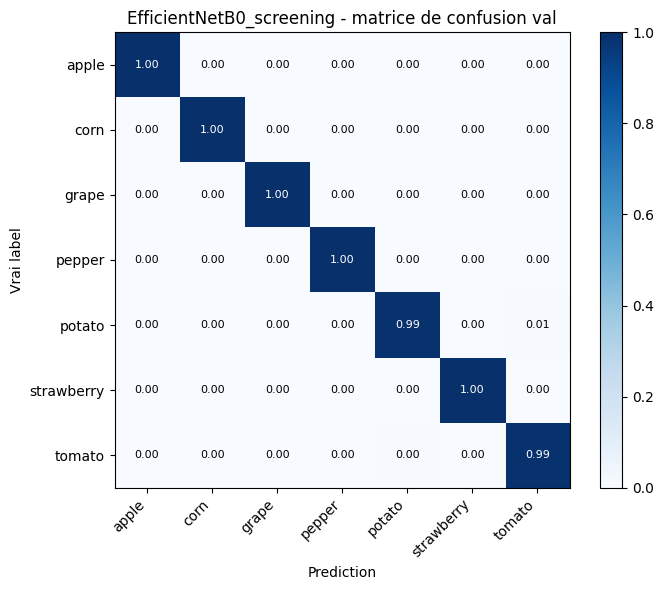

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
1,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406


In [11]:
inspect_model_results(
    "EfficientNetB0_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

### Screening - EfficientNetB1

In [12]:
efficientnet_b1_screening = run_species_phase1_screening(
    "EfficientNetB1",
    phase1_epochs=4,
)
efficientnet_b1_screening

2026-04-16 12:07:05.688 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / EfficientNetB1


Epoch 1/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 60s 31ms/step - accuracy: 0.9562 - loss: 0.1180 - val_accuracy: 0.9887 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9752 - loss: 0.0602 - val_accuracy: 0.9900 - val_loss: 0.0311 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 32s 22ms/step - accuracy: 0.9809 - loss: 0.0451 - val_accuracy: 0.9921 - val_loss: 0.0203 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 33s 22ms/step - accuracy: 0.9826 - loss: 0.0413 - val_accuracy: 0.9934 - val_loss: 0.0180 - learning_rate: 0.0010
🏃 View run species_screening_EfficientNetB1_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/38b251e426a64e22b4deba83a0e11799
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 12:11:04.681047: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🏃 View run EfficientNetB1_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/acae9d5d220d498b82244ff02d4c384a
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901
1,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406
2,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.995446,0.015524,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995446,0.004554,0.996197,0.995318,0.996197,0.995754,0.015524,7.327000,0.999604
5,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,None,0,0,0.993367,0.017985,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.993367,0.006633,0.995810,0.992325,0.995810,0.994049,0.017985,7.261799,0.999505
3,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.992278,0.022994,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.992278,0.007722,0.992050,0.992548,0.992050,0.992284,0.022994,8.197975,0.999505
4,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406


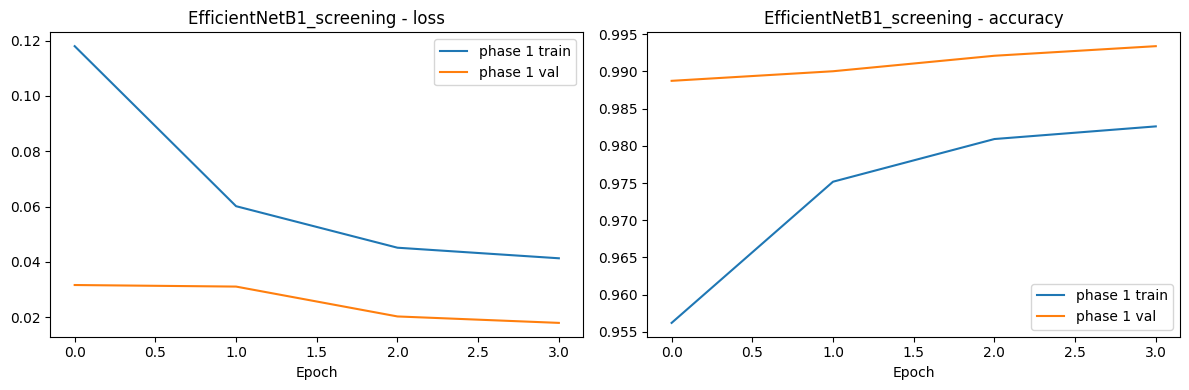

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
3,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.993367,0.017985,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.993367,0.006633,0.99581,0.992325,0.99581,0.994049,0.017985,7.261799,0.999505


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0108, gap loss val-train=-0.0233)


,precision,recall,f1-score,support
apple,0.983085,0.997255,0.990119,1457.000000
corn,1.000000,1.000000,1.000000,1373.000000
grape,0.994126,1.000000,0.997054,1354.000000
pepper,0.989189,1.000000,0.994565,732.000000
potato,0.986952,0.989720,0.988334,1070.000000
strawberry,0.995569,0.998519,0.997041,675.000000
tomato,0.997351,0.985174,0.991226,3440.000000
accuracy,0.993367,0.993367,0.993367,0.993367
macro avg,0.992325,0.995810,0.994049,10101.000000
weighted avg,0.993409,0.993367,0.993364,10101.000000


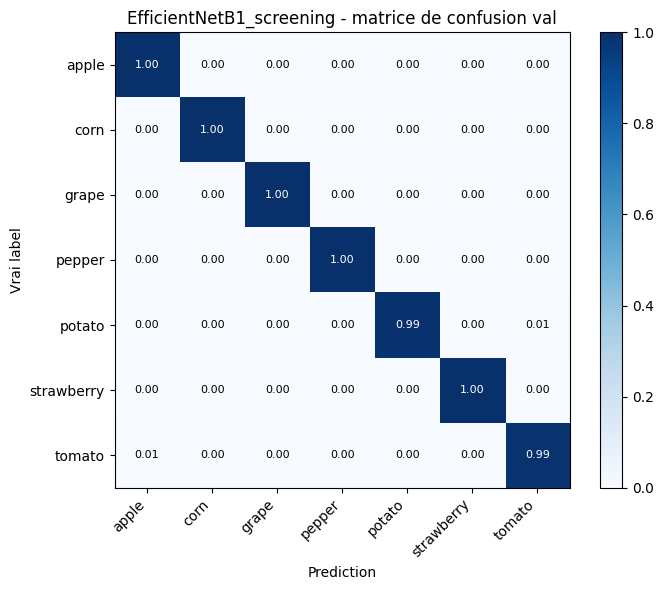

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
3,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.993367,0.017985,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.993367,0.006633,0.99581,0.992325,0.99581,0.994049,0.017985,7.261799,0.999505


In [13]:
inspect_model_results(
    "EfficientNetB1_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

### Screening - ConvNeXtTiny

In [14]:
convnext_tiny_screening = run_species_phase1_screening(
    "ConvNeXtTiny",
    phase1_epochs=4,
)
convnext_tiny_screening

2026-04-16 12:11:07.444 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / ConvNeXtTiny


Epoch 1/4


2026-04-16 12:11:14.901889: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 580 bytes spill stores, 580 bytes spill loads

2026-04-16 12:11:14.963971: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 484 bytes spill stores, 452 bytes spill loads

2026-04-16 12:11:14.989350: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 124 bytes spill stores, 124 bytes spill loads

2026-04-16 12:11:15.035570: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_12', 576 bytes spill stores, 480 bytes spill loads

2026-04-16 12:11:15.162251: I external/local_xla/

1471/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.9008 - loss: 0.2683

2026-04-16 12:11:47.707823: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 188 bytes spill stores, 188 bytes spill loads

2026-04-16 12:11:47.837055: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_30', 184 bytes spill stores, 184 bytes spill loads

2026-04-16 12:11:47.871492: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 476 bytes spill stores, 476 bytes spill loads

2026-04-16 12:11:47.917097: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 580 bytes spill stores, 580 bytes spill loads

2026-04-16 12:11:47.966677: I external/local_xla/

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9009 - loss: 0.2681

2026-04-16 12:11:54.210574: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 188 bytes spill stores, 188 bytes spill loads

2026-04-16 12:11:54.524976: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 448 bytes spill stores, 416 bytes spill loads

2026-04-16 12:11:54.543423: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 476 bytes spill stores, 476 bytes spill loads

2026-04-16 12:11:54.572862: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 124 bytes spill stores, 124 bytes spill loads

2026-04-16 12:11:54.598649: I external/local_xla/xla

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 66s 36ms/step - accuracy: 0.9519 - loss: 0.1254 - val_accuracy: 0.9864 - val_loss: 0.0391 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.9785 - loss: 0.0489 - val_accuracy: 0.9945 - val_loss: 0.0157 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 34s 23ms/step - accuracy: 0.9833 - loss: 0.0380 - val_accuracy: 0.9962 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 33s 23ms/step - accuracy: 0.9853 - loss: 0.0335 - val_accuracy: 0.9951 - val_loss: 0.0129 - learning_rate: 0.0010
🏃 View run species_screening_ConvNeXtTiny_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/92ff07090d7c40b8aad6262e119ef439
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0
🏃 View run ConvNeXtTiny_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901
5,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,None,0,0,0.996238,0.012871,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996238,0.003762,0.996225,0.996339,0.996225,0.996279,0.013562,8.005332,0.999802
1,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406
2,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.993367,0.017985,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.993367,0.006633,0.995810,0.992325,0.995810,0.994049,0.017985,7.261799,0.999505
3,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.992278,0.022994,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.992278,0.007722,0.992050,0.992548,0.992050,0.992284,0.022994,8.197975,0.999505
4,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406


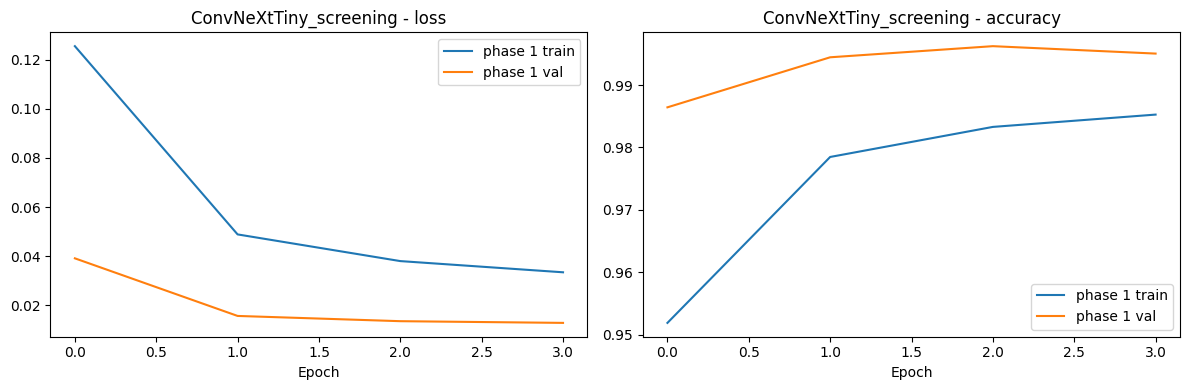

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.996238,0.012871,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996238,0.003762,0.996225,0.996339,0.996225,0.996279,0.013562,8.005332,0.999802


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0098, gap loss val-train=-0.0206)


,precision,recall,f1-score,support
apple,0.996573,0.997941,0.997257,1457.000000
corn,0.998544,0.999272,0.998908,1373.000000
grape,1.000000,0.996307,0.998150,1354.000000
pepper,0.997268,0.997268,0.997268,732.000000
potato,0.986059,0.991589,0.988816,1070.000000
strawberry,1.000000,0.995556,0.997773,675.000000
tomato,0.995929,0.995640,0.995784,3440.000000
accuracy,0.996238,0.996238,0.996238,0.996238
macro avg,0.996339,0.996225,0.996279,10101.000000
weighted avg,0.996247,0.996238,0.996241,10101.000000


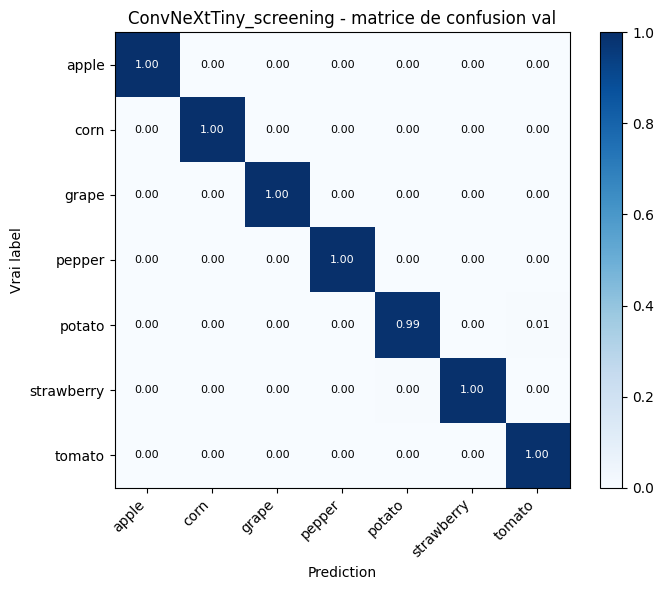

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.996238,0.012871,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996238,0.003762,0.996225,0.996339,0.996225,0.996279,0.013562,8.005332,0.999802


In [15]:
inspect_model_results(
    "ConvNeXtTiny_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

### Screening - DenseNet121

In [16]:
densenet_121_screening = run_species_phase1_screening(
    "DenseNet121",
    phase1_epochs=4,
)
densenet_121_screening

2026-04-16 12:15:25.717 | INFO     | src.models.train:train_model:61 - Phase 1: entrainement de la tete pour species_screening / DenseNet121


Epoch 1/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8625 - loss: 0.3701

2026-04-16 12:16:21.525691: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3302', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:16:21.663381: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3302_0', 184 bytes spill stores, 404 bytes spill loads

2026-04-16 12:16:21.680688: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3302', 104 bytes spill stores, 104 bytes spill loads

2026-04-16 12:16:21.946106: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_3302', 3988 bytes spill stores, 3972 bytes spill loads

2026-04-16 12:16:22.025045: I 

1473/1473 ━━━━━━━━━━━━━━━━━━━━ 83s 45ms/step - accuracy: 0.9219 - loss: 0.2012 - val_accuracy: 0.9820 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 2/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9575 - loss: 0.1025 - val_accuracy: 0.9558 - val_loss: 0.1292 - learning_rate: 0.0010
Epoch 3/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 40s 27ms/step - accuracy: 0.9622 - loss: 0.0867 - val_accuracy: 0.9789 - val_loss: 0.0602 - learning_rate: 0.0010
Epoch 4/4
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 42s 29ms/step - accuracy: 0.9676 - loss: 0.0732 - val_accuracy: 0.9893 - val_loss: 0.0303 - learning_rate: 0.0010
🏃 View run species_screening_DenseNet121_phase1 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/ad837444481f4e89b19596cf97e8a3e1
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0
🏃 View run DenseNet121_screening_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
0,MobileNetV3Large_screening,MobileNetV3Large,MobileNet,screening_phase1,0.001,NaN,0,0,0.996931,0.010149,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996931,0.003069,0.997106,0.996847,0.997106,0.996976,0.010149,6.295302,0.999901
1,ConvNeXtTiny_screening,ConvNeXtTiny,ConvNeXt,screening_phase1,0.001,NaN,0,0,0.996238,0.012871,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.996238,0.003762,0.996225,0.996339,0.996225,0.996279,0.013562,8.005332,0.999802
2,EfficientNetB0_screening,EfficientNetB0,EfficientNet,screening_phase1,0.001,NaN,0,0,0.995842,0.012308,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.995842,0.004158,0.996968,0.994581,0.996968,0.995768,0.012308,6.354599,0.999406
3,EfficientNetB1_screening,EfficientNetB1,EfficientNet,screening_phase1,0.001,NaN,0,0,0.993367,0.017985,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.993367,0.006633,0.995810,0.992325,0.995810,0.994049,0.017985,7.261799,0.999505
4,MobileNetV3Small_screening,MobileNetV3Small,MobileNet,screening_phase1,0.001,NaN,0,0,0.990991,0.025317,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.990991,0.009009,0.991156,0.990504,0.991156,0.990814,0.025317,6.132060,0.999406
5,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,None,0,0,0.989308,0.030295,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.989308,0.010692,0.994208,0.985646,0.994208,0.989781,0.030295,8.396584,0.999208


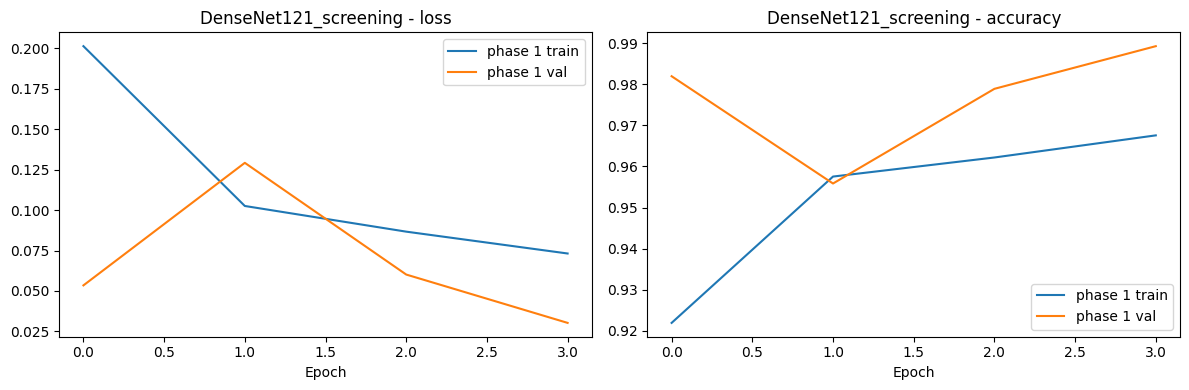

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
5,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.989308,0.030295,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.989308,0.010692,0.994208,0.985646,0.994208,0.989781,0.030295,8.396584,0.999208


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0217, gap loss val-train=-0.0429)


,precision,recall,f1-score,support
apple,0.985772,0.998627,0.992158,1457.000000
corn,0.999272,1.000000,0.999636,1373.000000
grape,0.996313,0.997784,0.997048,1354.000000
pepper,0.966887,0.997268,0.981843,732.000000
potato,0.951872,0.998131,0.974453,1070.000000
strawberry,1.000000,0.995556,0.997773,675.000000
tomato,0.999402,0.972093,0.985559,3440.000000
accuracy,0.989308,0.989308,0.989308,0.989308
macro avg,0.985646,0.994208,0.989781,10101.000000
weighted avg,0.989653,0.989308,0.989335,10101.000000


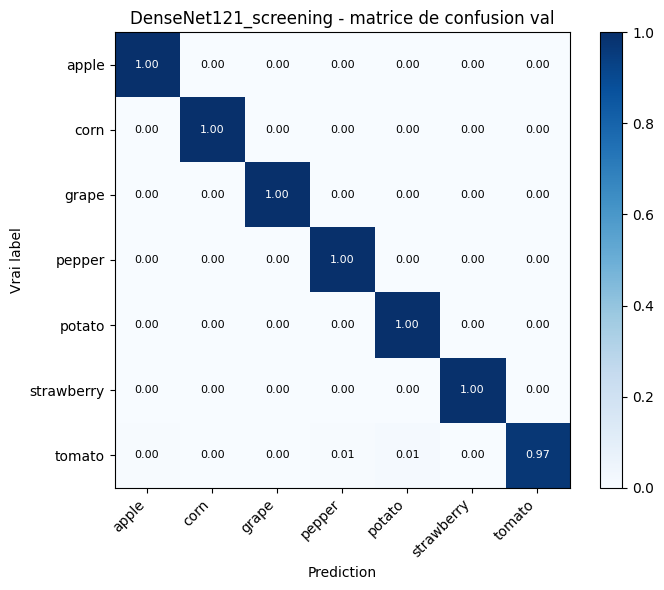

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,class_weight,eval_val_accuracy,eval_val_error_rate,eval_val_balanced_accuracy,eval_val_precision_macro,eval_val_recall_macro,eval_val_f1_macro,eval_val_log_loss,eval_val_ms_per_image,eval_val_top2_accuracy
5,DenseNet121_screening,DenseNet121,DenseNet,screening_phase1,0.001,NaN,0,0,0.989308,0.030295,...,"{0: 0.9900210084033614, 1: 1.0515687062078816,...",0.989308,0.010692,0.994208,0.985646,0.994208,0.989781,0.030295,8.396584,0.999208


In [17]:
inspect_model_results(
    "DenseNet121_screening",
    results_path=SCREENING_RESULTS_PATH,
    eval_name="val",
)

## Phase 2 - Fine-tuning des finalistes

On garde plus de 3 finalistes apres screening, par defaut 4, pour que la selection finale ne soit pas automatique par construction.

Le fine-tuning evalue ensuite val, test in-distribution et OOD PlantDoc. Le ranking final combine les metriques test, OOD, temps d'inference et overfitting, puis selectionne 3 modeles en favorisant la diversite de familles pour le vote doux.

In [18]:
# A ajuster apres lecture du screening_summary.
# Exemple: ["MobileNetV3Large", "EfficientNetB0", "DenseNet121"]
finalist_architectures = select_screening_finalists(top_k=4)
finalist_architectures

['MobileNetV3Large', 'EfficientNetB0', 'ConvNeXtTiny', 'EfficientNetB1']

In [19]:
# Option bulk si tu veux fine-tuner tous les finalistes d'un coup.
# Sinon, utilise les cellules manuelles ci-dessous.
# fine_tune_results = []
# for architecture in finalist_architectures:
#     fine_tune_results.append(
#         run_species_fine_tuning(
#             architecture,
#             fine_tune_layers=50,
#             phase2_learning_rate=1e-5,
#             phase2_epochs=10,
#         )
#     )

# rank_fine_tune_results()

## Option - Fine-tuning manuel

Ces cellules suivent automatiquement `finalist_architectures`. Si tu veux forcer une selection, modifie la cellule juste au-dessus avec une liste comme `finalist_architectures = ["EfficientNetB0", "ConvNeXtTiny", "MobileNetV3Large", "DenseNet121"]`.


### Fine-tuning - Finaliste 1


In [20]:
finalist_1_ft_l50 = run_finalist_fine_tuning(
    1,
    fine_tune_layers=50,
    phase2_learning_rate=1e-5,
    phase2_epochs=10,
)
finalist_1_ft_l50


Fine-tuning finaliste 1: MobileNetV3Large


2026-04-16 12:20:27.884 | INFO     | src.models.train:train_model:90 - Phase 2: fine-tuning de 16 couches du backbone pour species_ft_l50_lr1e_05 / MobileNetV3Large


Epoch 1/10


2026-04-16 12:20:35.101559: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:20:35.252200: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:20:35.831513: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:20:36.012352: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:20:36.208662: E external/local_xla/xla/stream_

1471/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9902 - loss: 0.0217

...

2026-04-16 12:28:02.057581: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:28:02.262801: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 16 bytes spill stores, 16 bytes spill loads

2026-04-16 12:28:02.337609: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 716 bytes spill stores, 720 bytes spill loads

2026-04-16 12:28:02.355465: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 248 bytes spill stores, 248 bytes spill loads

2026-04-16 12:28:02.443798: I extern

🏃 View run MobileNetV3Large_ft_l50_lr1e_05_eval_test at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/7518365793b24e8a80e90f882faf6b56
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 12:28:25.863525: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:28:26.119408: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 16 bytes spill stores, 16 bytes spill loads

2026-04-16 12:28:26.188750: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 248 bytes spill stores, 248 bytes spill loads

2026-04-16 12:28:26.206157: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1522', 716 bytes spill stores, 720 bytes spill loads

2026-04-16 12:28:26.311425: I extern

🏃 View run MobileNetV3Large_ft_l50_lr1e_05_eval_ood at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/243a8d9e19a24e8b8f63e561393e51df
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,1.000000,0.673988,0.326012,0.614138,0.653395,0.614138,0.598178,2.489401,8.675698,0.832041
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,NaN,NaN,...,1.000000,0.704565,0.295435,0.737477,0.648414,0.737477,0.670597,1.612747,9.816165,0.866494
2,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,None,None,...,0.999901,0.578811,0.421189,0.547390,0.592420,0.547390,0.521123,3.430132,9.276980,0.771748


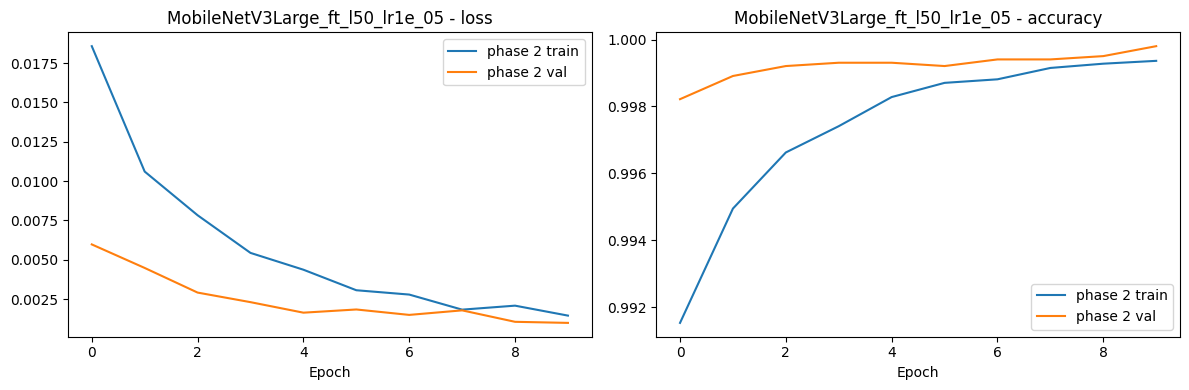

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
2,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,NaN,NaN,...,0.999901,0.578811,0.421189,0.54739,0.59242,0.54739,0.521123,3.430132,9.27698,0.771748


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0004, gap loss val-train=-0.0005)


,precision,recall,f1-score,support
apple,0.997945,1.000000,0.998972,1457.000000
corn,1.000000,1.000000,1.000000,1370.000000
grape,0.999263,1.000000,0.999631,1355.000000
pepper,0.998630,0.998630,0.998630,730.000000
potato,0.996265,0.999064,0.997662,1068.000000
strawberry,1.000000,1.000000,1.000000,674.000000
tomato,0.999709,0.997673,0.998690,3438.000000
accuracy,0.999009,0.999009,0.999009,0.999009
macro avg,0.998830,0.999338,0.999084,10092.000000
weighted avg,0.999011,0.999009,0.999009,10092.000000


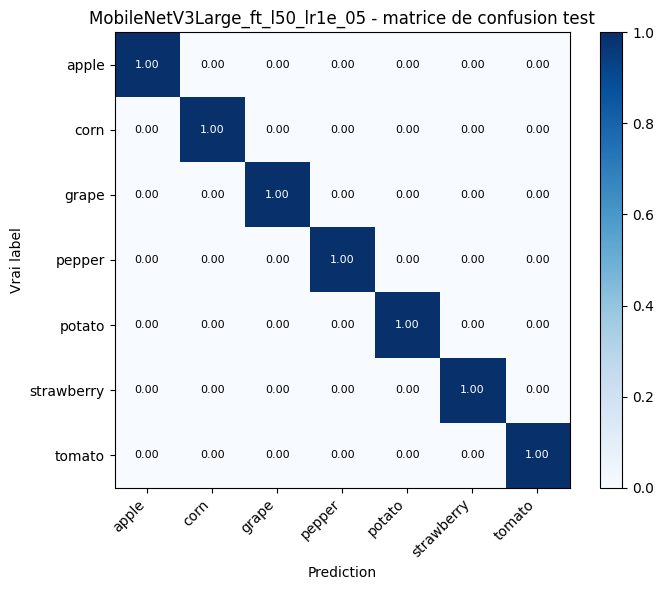

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
2,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,NaN,NaN,...,0.999901,0.578811,0.421189,0.54739,0.59242,0.54739,0.521123,3.430132,9.27698,0.771748


In [21]:
inspect_finalist_fine_tuning(1)


### Fine-tuning - Finaliste 2


In [22]:
finalist_2_ft_l50 = run_finalist_fine_tuning(
    2,
    fine_tune_layers=50,
    phase2_learning_rate=1e-5,
    phase2_epochs=10,
)
finalist_2_ft_l50


Fine-tuning finaliste 2: EfficientNetB0


2026-04-16 12:28:34.117 | INFO     | src.models.train:train_model:90 - Phase 2: fine-tuning de 17 couches du backbone pour species_ft_l50_lr1e_05 / EfficientNetB0


Epoch 1/10


2026-04-16 12:28:45.141370: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:28:45.354694: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:28:45.567625: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-04-16 12:28:45.761179: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1469/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9925 - loss: 0.0189

...

2026-04-16 12:37:32.740280: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:37:32.888894: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031_0', 176 bytes spill stores, 524 bytes spill loads

2026-04-16 12:37:32.914359: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 104 bytes spill stores, 104 bytes spill loads

2026-04-16 12:37:33.204342: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 4480 bytes spill stores, 4524 bytes spill loads

2026-04-16 12:37:33.282203: I 

🏃 View run EfficientNetB0_ft_l50_lr1e_05_eval_test at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/ff220bf42d934f5689f3483fb17c7ad9
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 12:37:57.874694: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 12 bytes spill stores, 12 bytes spill loads

2026-04-16 12:37:57.949139: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031_0', 176 bytes spill stores, 524 bytes spill loads

2026-04-16 12:37:58.035150: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 104 bytes spill stores, 104 bytes spill loads

2026-04-16 12:37:58.329711: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_2031', 4460 bytes spill stores, 4504 bytes spill loads

2026-04-16 12:37:58.407501: I 

🏃 View run EfficientNetB0_ft_l50_lr1e_05_eval_ood at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/03a24a8d6c354b5f93aa282c4d84a24d
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
2,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,None,None,...,1.000000,0.676141,0.323859,0.627862,0.652486,0.627862,0.605973,2.292395,8.420921,0.835056
0,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,NaN,NaN,...,1.000000,0.704565,0.295435,0.737477,0.648414,0.737477,0.670597,1.612747,9.816165,0.866494
1,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,NaN,NaN,...,0.999901,0.578811,0.421189,0.547390,0.592420,0.547390,0.521123,3.430132,9.276980,0.771748


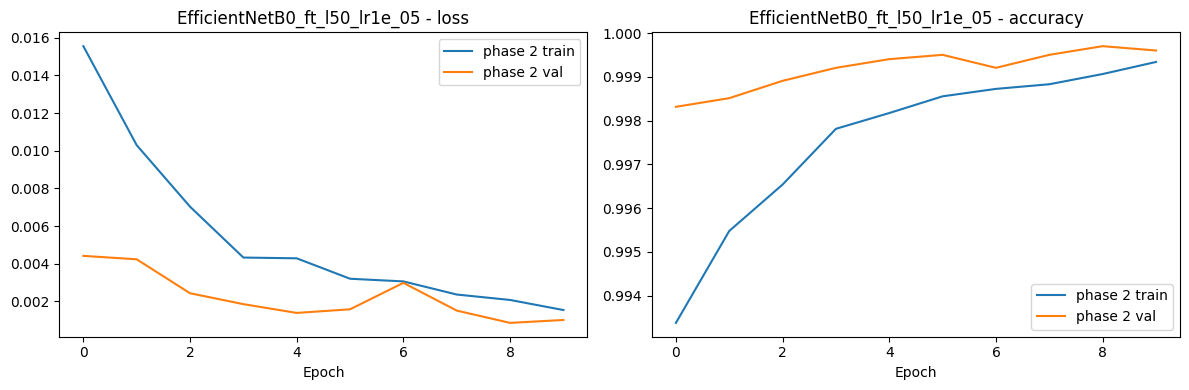

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,1.0,0.676141,0.323859,0.627862,0.652486,0.627862,0.605973,2.292395,8.420921,0.835056


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0003, gap loss val-train=-0.0005)


,precision,recall,f1-score,support
apple,0.999314,1.000000,0.999657,1457.000000
corn,1.000000,1.000000,1.000000,1370.000000
grape,0.999263,1.000000,0.999631,1355.000000
pepper,1.000000,1.000000,1.000000,730.000000
potato,0.999065,1.000000,0.999532,1068.000000
strawberry,1.000000,1.000000,1.000000,674.000000
tomato,1.000000,0.999127,0.999564,3438.000000
accuracy,0.999703,0.999703,0.999703,0.999703
macro avg,0.999663,0.999875,0.999769,10092.000000
weighted avg,0.999703,0.999703,0.999703,10092.000000


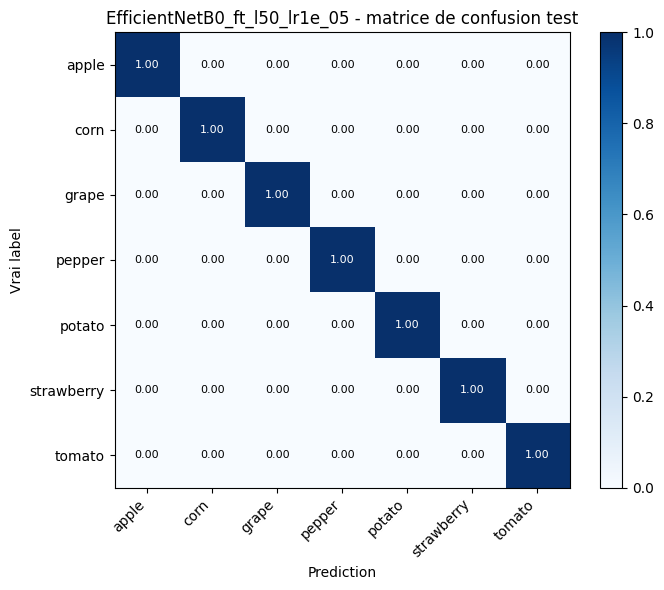

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,1.0,0.676141,0.323859,0.627862,0.652486,0.627862,0.605973,2.292395,8.420921,0.835056


In [23]:
inspect_finalist_fine_tuning(2)


### Fine-tuning - Finaliste 3


In [24]:
finalist_3_ft_l50 = run_finalist_fine_tuning(
    3,
    fine_tune_layers=50,
    phase2_learning_rate=1e-5,
    phase2_epochs=10,
)
finalist_3_ft_l50


Fine-tuning finaliste 3: ConvNeXtTiny


2026-04-16 12:38:07.892 | INFO     | src.models.train:train_model:90 - Phase 2: fine-tuning de 36 couches du backbone pour species_ft_l50_lr1e_05 / ConvNeXtTiny


Epoch 1/10


2026-04-16 12:38:18.072610: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-04-16 12:38:21.539780: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_36', 40 bytes spill stores, 40 bytes spill loads

2026-04-16 12:38:21.750172: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_36', 260 bytes spill stores, 260 bytes spill loads

2026-04-16 12:38:21.830909: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fus

1472/1473 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.9905 - loss: 0.0211

...

2026-04-16 13:04:57.600025: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 188 bytes spill stores, 188 bytes spill loads

2026-04-16 13:04:57.709384: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 448 bytes spill stores, 416 bytes spill loads

2026-04-16 13:04:57.756993: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 776 bytes spill stores, 776 bytes spill loads

2026-04-16 13:04:57.875780: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_1', 184 bytes spill stores, 184 bytes spill loads

2026-04-16 13:04:57.876306: I external/local_xla/x

🏃 View run ConvNeXtTiny_ft_l50_lr1e_05_eval_test at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/a87b6e26998a431a87ff196866fe2ad0
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 13:05:21.566284: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 188 bytes spill stores, 188 bytes spill loads

2026-04-16 13:05:21.757003: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 124 bytes spill stores, 124 bytes spill loads

2026-04-16 13:05:21.771634: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 580 bytes spill stores, 580 bytes spill loads

2026-04-16 13:05:21.839119: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot', 776 bytes spill stores, 776 bytes spill loads

2026-04-16 13:05:21.924207: I external/local_xla/xla

🏃 View run ConvNeXtTiny_ft_l50_lr1e_05_eval_ood at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/f33f34e58ede464fb5d441125b3dd343
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,1.000000,0.676141,0.323859,0.627862,0.652486,0.627862,0.605973,2.292395,8.420921,0.835056
2,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,None,None,...,1.000000,0.739449,0.260551,0.740988,0.682005,0.740988,0.704791,1.479190,9.589077,0.892334
1,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,NaN,NaN,...,0.999901,0.578811,0.421189,0.547390,0.592420,0.547390,0.521123,3.430132,9.276980,0.771748


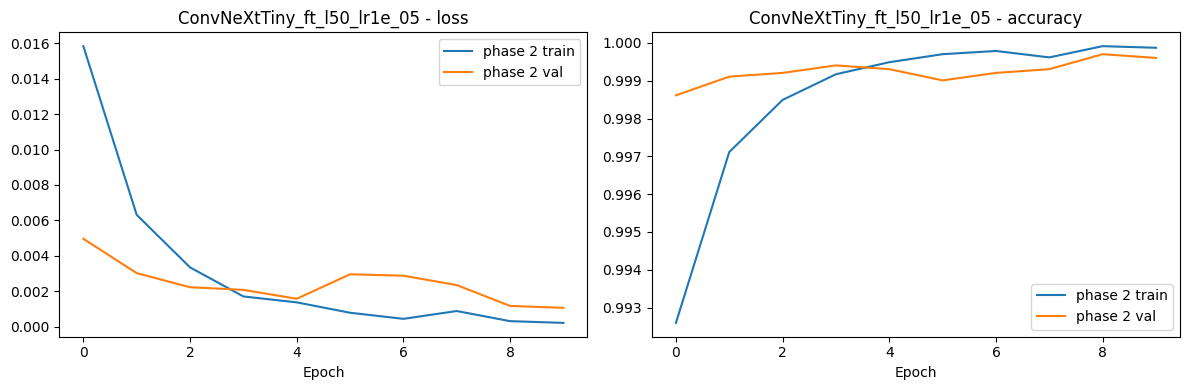

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,NaN,NaN,...,1.0,0.739449,0.260551,0.740988,0.682005,0.740988,0.704791,1.47919,9.589077,0.892334


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=0.0003, gap loss val-train=0.0009)


,precision,recall,f1-score,support
apple,0.999314,1.000000,0.999657,1457.000000
corn,1.000000,1.000000,1.000000,1370.000000
grape,0.999263,1.000000,0.999631,1355.000000
pepper,0.998632,1.000000,0.999316,730.000000
potato,0.998131,1.000000,0.999065,1068.000000
strawberry,1.000000,1.000000,1.000000,674.000000
tomato,1.000000,0.998546,0.999272,3438.000000
accuracy,0.999505,0.999505,0.999505,0.999505
macro avg,0.999334,0.999792,0.999563,10092.000000
weighted avg,0.999505,0.999505,0.999505,10092.000000


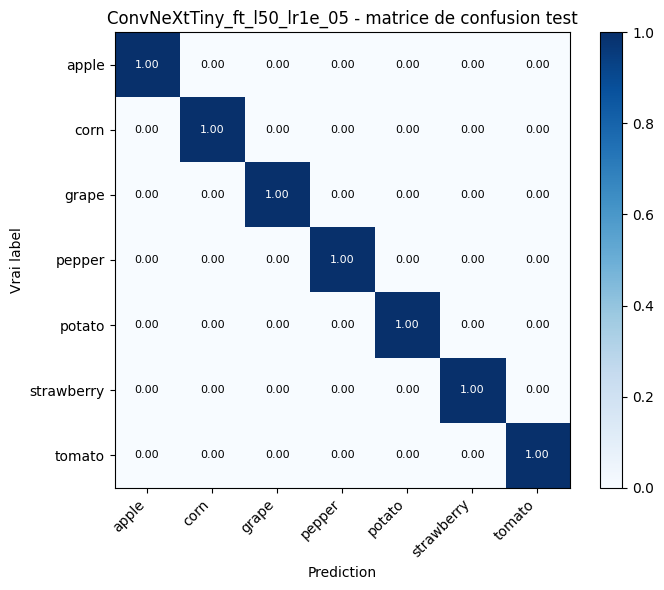

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,NaN,NaN,...,1.0,0.739449,0.260551,0.740988,0.682005,0.740988,0.704791,1.47919,9.589077,0.892334


In [25]:
inspect_finalist_fine_tuning(3)


### Fine-tuning - Finaliste 4


In [26]:
finalist_4_ft_l50 = run_finalist_fine_tuning(
    4,
    fine_tune_layers=50,
    phase2_learning_rate=1e-5,
    phase2_epochs=10,
)
finalist_4_ft_l50


Fine-tuning finaliste 4: EfficientNetB1


2026-04-16 13:05:31.085 | INFO     | src.models.train:train_model:90 - Phase 2: fine-tuning de 17 couches du backbone pour species_ft_l50_lr1e_05 / EfficientNetB1


Epoch 1/10
1473/1473 ━━━━━━━━━━━━━━━━━━━━ 72s 37ms/step - accuracy: 0.9910 - loss: 0.0201 - val_accuracy: 0.9969 - val_loss: 0.0078 - learning_rate: 1.0000e-05
Epoch 2/10
   5/1473 ━━━━━━━━━━━━━━━━━━━━ 43s 30ms/step - accuracy: 1.0000 - loss: 7.3652e-04

2026-04-16 13:06:44.359321: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 33554816 bytes after encountering the first element of size 33554816 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


1473/1473 ━━━━━━━━━━━━━━━━━━━━ 37s 25ms/step - accuracy: 0.9944 - loss: 0.0111 - val_accuracy: 0.9989 - val_loss: 0.0035 - learning_rate: 1.0000e-05
Epoch 3/10
   7/1473 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 1.0000 - loss: 6.4543e-04

...

2026/04/16 13:12:18 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model without a signature. Inference with mlflow.pyfunc.spark_udf() will not work unless the model's pyfunc representation accepts pandas DataFrames as inference inputs.
2026/04/16 13:13:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


🏃 View run species_ft_l50_lr1e_05_EfficientNetB1_phase2 at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/00ec0246e06642be9792ea4a9e9f646e
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


2026-04-16 13:15:16.378611: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


🏃 View run EfficientNetB1_ft_l50_lr1e_05_eval_val at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/ef8f33f90f734c99a6db0b10c64a9a35
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0
🏃 View run EfficientNetB1_ft_l50_lr1e_05_eval_test at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/f035226120b34c91852b5bcae947475a
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0
🏃 View run EfficientNetB1_ft_l50_lr1e_05_eval_ood at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0/runs/2d26a7527dde45a0868725937227cbc0
🧪 View experiment at: https://dagshub.com/thomashebert99/Plant-disease-detection.mlflow/#/experiments/0


,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNetB0,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,1.000000,0.676141,0.323859,0.627862,0.652486,0.627862,0.605973,2.292395,8.420921,0.835056
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXtTiny,ConvNeXt,fine_tuning,0.001,0.00001,36,50,NaN,NaN,...,1.000000,0.739449,0.260551,0.740988,0.682005,0.740988,0.704791,1.479190,9.589077,0.892334
3,EfficientNetB1_ft_l50_lr1e_05,EfficientNetB1,EfficientNet,fine_tuning,0.001,0.00001,17,50,None,None,...,0.999901,0.714040,0.285960,0.675597,0.664698,0.675597,0.651511,1.770243,8.283679,0.867786
2,MobileNetV3Large_ft_l50_lr1e_05,MobileNetV3Large,MobileNet,fine_tuning,0.001,0.00001,16,50,NaN,NaN,...,0.999901,0.578811,0.421189,0.547390,0.592420,0.547390,0.521123,3.430132,9.276980,0.771748


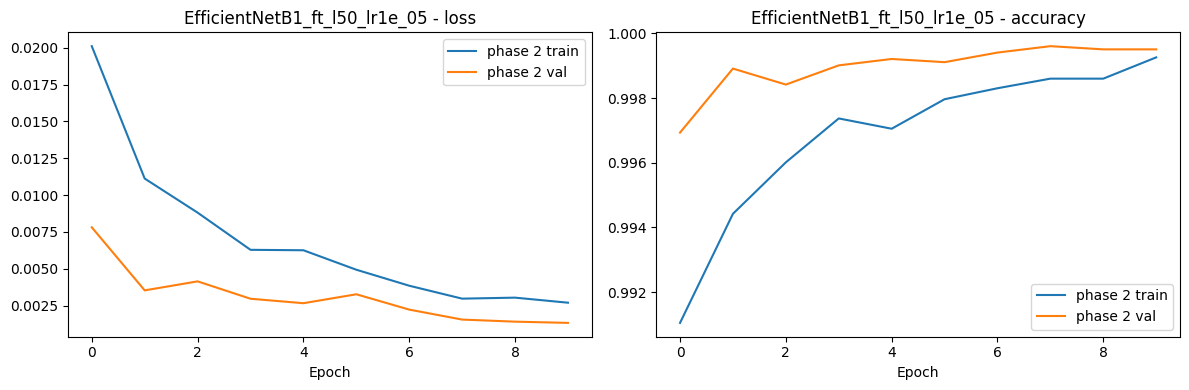

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
2,EfficientNetB1_ft_l50_lr1e_05,EfficientNetB1,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,0.999901,0.71404,0.28596,0.675597,0.664698,0.675597,0.651511,1.770243,8.283679,0.867786


Diagnostic overfitting: pas_d_overfitting_significatif (gap accuracy train-val=-0.0002, gap loss val-train=-0.0014)


,precision,recall,f1-score,support
apple,0.998629,1.000000,0.999314,1457.000000
corn,1.000000,1.000000,1.000000,1370.000000
grape,0.999263,1.000000,0.999631,1355.000000
pepper,0.998630,0.998630,0.998630,730.000000
potato,0.998131,1.000000,0.999065,1068.000000
strawberry,1.000000,1.000000,1.000000,674.000000
tomato,1.000000,0.998546,0.999272,3438.000000
accuracy,0.999405,0.999405,0.999405,0.999405
macro avg,0.999236,0.999597,0.999416,10092.000000
weighted avg,0.999406,0.999405,0.999405,10092.000000


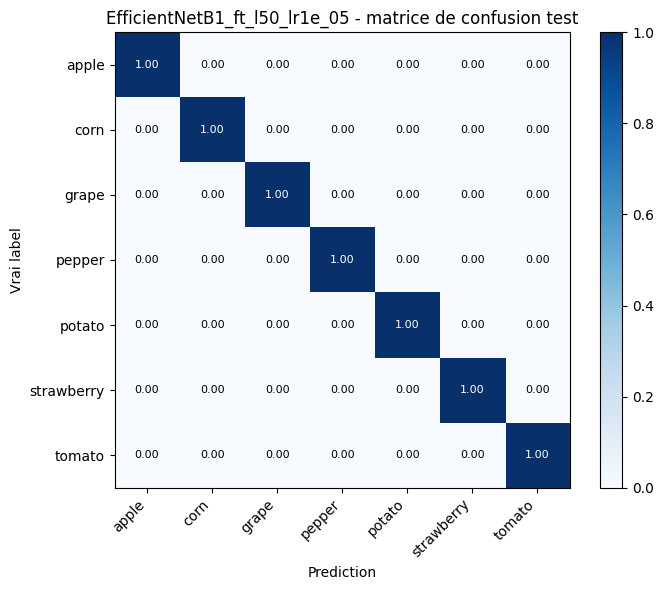

,run_name,architecture,architecture_family,stage,phase1_learning_rate,phase2_learning_rate,fine_tuned_layers,requested_fine_tune_layers,phase1_best_val_accuracy,phase1_best_val_loss,...,eval_test_top2_accuracy,eval_ood_accuracy,eval_ood_error_rate,eval_ood_balanced_accuracy,eval_ood_precision_macro,eval_ood_recall_macro,eval_ood_f1_macro,eval_ood_log_loss,eval_ood_ms_per_image,eval_ood_top2_accuracy
2,EfficientNetB1_ft_l50_lr1e_05,EfficientNetB1,EfficientNet,fine_tuning,0.001,0.00001,17,50,NaN,NaN,...,0.999901,0.71404,0.28596,0.675597,0.664698,0.675597,0.651511,1.770243,8.283679,0.867786


In [27]:
inspect_finalist_fine_tuning(4)


## Synthese

Le choix final retient 3 modeles pour l'ensemble par vote doux. La selection automatique sert de base objective; elle doit rester validable par lecture des matrices de confusion, de l'OOD PlantDoc et de l'UI DagsHub/MLflow.

In [31]:
screening_ranking = rank_screening_results()
finetune_ranking = rank_fine_tune_results()
final_ensemble = select_final_ensemble(top_k=3)
screening_ranking, finetune_ranking, final_ensemble

(                     run_name      architecture architecture_family  \
 0  MobileNetV3Large_screening  MobileNetV3Large           MobileNet   
 2    EfficientNetB0_screening    EfficientNetB0        EfficientNet   
 1      ConvNeXtTiny_screening      ConvNeXtTiny            ConvNeXt   
 3    EfficientNetB1_screening    EfficientNetB1        EfficientNet   
 4  MobileNetV3Small_screening  MobileNetV3Small           MobileNet   
 5       DenseNet121_screening       DenseNet121            DenseNet   
 
               stage  phase1_learning_rate  phase2_learning_rate  \
 0  screening_phase1                 0.001                   NaN   
 2  screening_phase1                 0.001                   NaN   
 1  screening_phase1                 0.001                   NaN   
 3  screening_phase1                 0.001                   NaN   
 4  screening_phase1                 0.001                   NaN   
 5  screening_phase1                 0.001                   NaN   
 
    fine_tuned_l

In [32]:
final_ensemble = select_final_ensemble(top_k=3)
selected_species_models = final_ensemble["run_name"].tolist() if not final_ensemble.empty else []
selection_notes = (
    "Selection automatique par score multi-metriques avec diversite de familles. "
    "A valider visuellement dans DagsHub et avec les matrices de confusion."
)
selected_species_models, selection_notes

(['EfficientNetB0_ft_l50_lr1e_05',
  'ConvNeXtTiny_ft_l50_lr1e_05',
  'EfficientNetB1_ft_l50_lr1e_05'],
 'Selection automatique par score multi-metriques avec diversite de familles. A valider visuellement dans DagsHub et avec les matrices de confusion.')

In [33]:
final_ensemble[
    [
        "run_name",
        "architecture_family",
        "ranking_score",
        "eval_test_f1_macro",
        "eval_test_balanced_accuracy",
        "eval_ood_f1_macro",
        "eval_ood_balanced_accuracy",
        "eval_test_log_loss",
        "eval_test_ms_per_image",
        "overfit_diagnostic",
    ]
]


,run_name,architecture_family,ranking_score,eval_test_f1_macro,eval_test_balanced_accuracy,eval_ood_f1_macro,eval_ood_balanced_accuracy,eval_test_log_loss,eval_test_ms_per_image,overfit_diagnostic
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNet,0.8125,0.999769,0.999875,0.605973,0.627862,0.001299,6.629629,pas_d_overfitting_significatif
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXt,0.7875,0.999563,0.999792,0.704791,0.740988,0.001304,7.901912,pas_d_overfitting_significatif
2,EfficientNetB1_ft_l50_lr1e_05,EfficientNet,0.6125,0.999416,0.999597,0.651511,0.675597,0.003119,6.977836,pas_d_overfitting_significatif


In [34]:
rank_fine_tune_results()[
    [
        "run_name",
        "architecture_family",
        "ranking_score",
        "eval_test_f1_macro",
        "eval_ood_f1_macro",
        "eval_ood_balanced_accuracy",
    ]
]

,run_name,architecture_family,ranking_score,eval_test_f1_macro,eval_ood_f1_macro,eval_ood_balanced_accuracy
0,EfficientNetB0_ft_l50_lr1e_05,EfficientNet,0.8125,0.999769,0.605973,0.627862
1,ConvNeXtTiny_ft_l50_lr1e_05,ConvNeXt,0.7875,0.999563,0.704791,0.740988
2,EfficientNetB1_ft_l50_lr1e_05,EfficientNet,0.6125,0.999416,0.651511,0.675597
3,MobileNetV3Large_ft_l50_lr1e_05,MobileNet,0.2875,0.999084,0.521123,0.547390
